In [1]:
# Instalación de dependencias (ejecuta solo si es necesario)
# DINOv3 requiere transformers >= 4.56.0
# !pip install "transformers>=4.56.0" torch torchvision pillow requests scikit-learn seaborn supervision ultralytics opencv-python

import importlib

# Lista de paquetes a verificar (nombre de importación -> nombre pip si difiere)
paquetes = [
    ("transformers",  None),
    ("torch",         None),
    ("torchvision",   None),
    ("sklearn",       "scikit-learn"),
    ("PIL",           "pillow"),
    ("cv2",           "opencv-python"),
    ("supervision",   None),
    ("seaborn",       None),
    ("matplotlib",    None),
    ("ultralytics",   None),
    ("requests",      None),
]

todos_ok = True
for nombre_import, nombre_pip in paquetes:
    nombre_pip = nombre_pip or nombre_import
    try:
        mod = importlib.import_module(nombre_import)
        version = getattr(mod, "__version__", "(sin version)")
        print(f"  ok  {nombre_import:<15} {version}")
    except ImportError:
        print(f"  FALTA {nombre_import:<12} -> instala con: pip install {nombre_pip}")
        todos_ok = False

if todos_ok:
    print("\nTodas las dependencias están instaladas.")
else:
    print("\nInstala los paquetes faltantes y vuelve a ejecutar esta celda.")


  ok  transformers    5.10.2
  ok  torch           2.12.0+cu130
  ok  torchvision     0.27.0+cu130
  ok  sklearn         1.9.0
  ok  PIL             12.2.0
  ok  cv2             4.13.0
  ok  supervision     0.28.0
  ok  seaborn         0.13.2
  ok  matplotlib      3.10.9
  ok  ultralytics     8.4.56
  ok  requests        2.34.2

Todas las dependencias están instaladas.


In [2]:
# Demo rapida: similitud entre pares de imagenes
# Ejecuta y observa los numeros. La explicacion viene en la Seccion 3.

import torch
import torch.nn.functional as F
from transformers import AutoImageProcessor, AutoModel
from PIL import Image
import requests
from io import BytesIO

# Detectar si hay GPU disponible
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Dispositivo: {device}")

# Cargar modelo DINOv3 (se descarga ~50 MB la primera vez)
print("Cargando DINOv3... (puede tardar 30 segundos la primera vez)")
MODELO_ID = "facebook/dinov3-convnext-tiny-pretrain-lvd1689m"
_proc_demo  = AutoImageProcessor.from_pretrained(MODELO_ID)
_model_demo = AutoModel.from_pretrained(MODELO_ID).to(device)
# modo evaluacion: desactiva dropout y batchnorm dinamico
_model_demo.train(False)
print("Modelo listo.")


def _demo_embedding(url: str) -> torch.Tensor:
    """Obtiene embedding normalizado de una URL de imagen."""
    resp = requests.get(url, timeout=15)
    img  = Image.open(BytesIO(resp.content)).convert("RGB")
    inps = _proc_demo(images=img, return_tensors="pt").to(device)
    with torch.no_grad():
        emb = _model_demo(**inps).pooler_output
    return F.normalize(emb, dim=-1)


url_perro  = "https://www.williamwalker.de/cdn/shop/articles/friendsofwilliamwalker_BorderCollie4zu3_c2a110eb-eb77-4f54-a81d-ca29e675e14f.jpg?v=1742998563&width=1400"
url_auto   = "https://emea-dam.audi.com/adobe/assets/urn:aaid:aem:52af229c-e3de-4535-b020-07d8b7a9533a/as/promo_a3_sedan.jpg?width=1422&auto=webp"
url_perro2 = "https://ask.woodgreen.org.uk/media/pages/images/a688e479f4-1727379906/border-collie-2-1200x1200-crop-53-8-30-4.webp"

print("Descargando imagenes de demo...")
emb_perro  = _demo_embedding(url_perro)
emb_auto   = _demo_embedding(url_auto)
emb_perro2 = _demo_embedding(url_perro2)

sim_pp = F.cosine_similarity(emb_perro, emb_perro2).item()
sim_pa = F.cosine_similarity(emb_perro, emb_auto).item()
sim_aa = F.cosine_similarity(emb_auto,  emb_auto).item()

print("\n── Similitudes visuales ─────────────────────────────")
print(f"  Perro vs Perro (dos fotos de perros): {sim_pp:.4f}")
print(f"  Perro vs Auto  (categorias distintas): {sim_pa:.4f}")
print(f"  Auto  vs Auto  (imagen identica):      {sim_aa:.4f}")
print("\nObserva: dos perros tienen similitud MAS ALTA que perro+auto.")
print("Eso es DINOv3 capturando el significado visual sin etiquetas.")



Dispositivo: cpu
Cargando DINOv3... (puede tardar 30 segundos la primera vez)


Loading weights:   0%|          | 0/180 [00:00<?, ?it/s]

Modelo listo.
Descargando imagenes de demo...

── Similitudes visuales ─────────────────────────────
  Perro vs Perro (dos fotos de perros): 0.8559
  Perro vs Auto  (categorias distintas): 0.0241
  Auto  vs Auto  (imagen identica):      1.0000

Observa: dos perros tienen similitud MAS ALTA que perro+auto.
Eso es DINOv3 capturando el significado visual sin etiquetas.


In [3]:
# Funcion principal: get_embedding
# Acepta URL de internet o ruta local. Devuelve tensor normalizado [1, 768].

def get_embedding(
    image_source: str,
    processor: AutoImageProcessor,
    model: AutoModel,
    device: str = "cpu"
) -> torch.Tensor:
    """
    Extrae el embedding normalizado de una imagen.

    Parametros:
        image_source: URL (http/https) o ruta local al archivo de imagen
        processor:    AutoImageProcessor cargado desde HuggingFace
        model:        AutoModel cargado desde HuggingFace
        device:       cuda o cpu

    Retorna:
        torch.Tensor de shape [1, 768], normalizado (norma = 1.0)
    """
    # Cargar imagen desde URL o ruta local
    if image_source.startswith("http://") or image_source.startswith("https://"):
        try:
            respuesta = requests.get(image_source, timeout=15)
            respuesta.raise_for_status()  # lanza error si el status no es 200
            imagen = Image.open(BytesIO(respuesta.content)).convert("RGB")
        except Exception as e:
            raise RuntimeError(f"Error al descargar imagen desde {image_source}: {e}")
    else:
        try:
            imagen = Image.open(image_source).convert("RGB")
        except Exception as e:
            raise RuntimeError(f"Error al abrir imagen local {image_source}: {e}")

    # Preprocesar: resize a 224x224, normalizar con media y std de ImageNet
    inputs = processor(images=imagen, return_tensors="pt").to(device)

    # Inferencia sin gradientes (mas rapido, menos memoria)
    with torch.no_grad():
        salida = model(**inputs)

    # pooler_output: vector global que resume toda la imagen [1, 768]
    embedding = salida.pooler_output

    # Normalizar a norma 1 para que cosine similarity = producto punto
    embedding_normalizado = F.normalize(embedding, dim=-1)

    return embedding_normalizado


print("Funcion get_embedding() definida.")
print("Acepta URL o ruta local, devuelve tensor normalizado [1, 768].")


Funcion get_embedding() definida.
Acepta URL o ruta local, devuelve tensor normalizado [1, 768].


In [4]:
import torch
import torch.nn.functional as F

# Vectores de ejemplo de 3 dimensiones
v_perro   = torch.tensor([[0.9, 0.8, 0.1]])  # calido, peludo
v_gato    = torch.tensor([[0.8, 0.7, 0.2]])  # similar al perro
v_paisaje = torch.tensor([[0.2, 0.9, 0.8]])  # mas frio, azul/verde

# Normalizar cada vector a longitud 1
v_perro_n   = F.normalize(v_perro,   dim=-1)
v_gato_n    = F.normalize(v_gato,    dim=-1)
v_paisaje_n = F.normalize(v_paisaje, dim=-1)

# Calcular similitud coseno entre pares
sim_pg  = F.cosine_similarity(v_perro_n, v_gato_n).item()
sim_pp  = F.cosine_similarity(v_perro_n, v_paisaje_n).item()
sim_pp2 = F.cosine_similarity(v_perro_n, v_perro_n).item()

print("Cosine similarity con vectores de 3 dimensiones:")
print(f"  Perro   vs Gato:     {sim_pg:.4f}  <- similares")
print(f"  Perro   vs Paisaje:  {sim_pp:.4f}  <- distintos")
print(f"  Perro   vs si mismo: {sim_pp2:.4f}  <- identico = 1.0")
print()
print("Rango: -1.0 (opuestos) -> 0.0 (sin relacion) -> 1.0 (identicos)")
print("Con imagenes reales los vectores tienen 768 dimensiones, no 3,")
print("pero el concepto es exactamente el mismo.")


Cosine similarity con vectores de 3 dimensiones:
  Perro   vs Gato:     0.9947  <- similares
  Perro   vs Paisaje:  0.6644  <- distintos
  Perro   vs si mismo: 1.0000  <- identico = 1.0

Rango: -1.0 (opuestos) -> 0.0 (sin relacion) -> 1.0 (identicos)
Con imagenes reales los vectores tienen 768 dimensiones, no 3,
pero el concepto es exactamente el mismo.


In [5]:
# Imports y setup
import torch
import torch.nn.functional as F
from transformers import AutoImageProcessor, AutoModel
from PIL import Image
import requests
from io import BytesIO
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import cv2

# Crear carpeta para guardar imagenes descargadas
ASSETS_DIR = Path("assets/dinov3")
ASSETS_DIR.mkdir(parents=True, exist_ok=True)

# Detectar dispositivo: GPU si esta disponible, si no CPU
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Dispositivo seleccionado: {device}")
if device == "cpu":
    print("(En CPU DINOv3 tarda ~1-2 s por imagen. Con GPU seria ~0.05 s)")

# Cargar el procesador y el modelo DINOv3
# AutoImageProcessor: prepara las imagenes para el modelo (resize, normalize)
# AutoModel: la red neuronal que genera los embeddings
MODELO_ID = "facebook/dinov3-convnext-tiny-pretrain-lvd1689m"
print(f"\nCargando modelo: {MODELO_ID}")
print("(~50 MB, se descarga una vez y queda en cache)")

processor = AutoImageProcessor.from_pretrained(MODELO_ID)
model = AutoModel.from_pretrained(MODELO_ID).to(device)
# train(False) equivale a model.train(mode=False) -> modo evaluacion sin dropout
model.train(False)

# Verificar dimension del embedding con una imagen de prueba
_dummy_img    = Image.new("RGB", (224, 224))
_dummy_inputs = processor(images=_dummy_img, return_tensors="pt").to(device)
with torch.no_grad():
    _emb_dim = model(**_dummy_inputs).pooler_output.shape[-1]

print(f"\nModelo cargado correctamente.")
print(f"Dimension del embedding: {_emb_dim} numeros por imagen")


Dispositivo seleccionado: cpu
(En CPU DINOv3 tarda ~1-2 s por imagen. Con GPU seria ~0.05 s)

Cargando modelo: facebook/dinov3-convnext-tiny-pretrain-lvd1689m
(~50 MB, se descarga una vez y queda en cache)


Loading weights:   0%|          | 0/180 [00:00<?, ?it/s]


Modelo cargado correctamente.
Dimension del embedding: 768 numeros por imagen


In [6]:
# Funcion principal: get_embedding
# Acepta URL de internet o ruta local. Devuelve tensor normalizado [1, 768].

def get_embedding(
    image_source: str,
    processor: AutoImageProcessor,
    model: AutoModel,
    device: str = "cpu"
) -> torch.Tensor:
    """
    Extrae el embedding normalizado de una imagen.

    Parametros:
        image_source: URL (http/https) o ruta local al archivo de imagen
        processor:    AutoImageProcessor cargado desde HuggingFace
        model:        AutoModel cargado desde HuggingFace
        device:       cuda o cpu

    Retorna:
        torch.Tensor de shape [1, 768], normalizado (norma = 1.0)
    """
    # Cargar imagen desde URL o ruta local
    if image_source.startswith("http://") or image_source.startswith("https://"):
        try:
            respuesta = requests.get(image_source, timeout=15)
            respuesta.raise_for_status()  # lanza error si el status no es 200
            imagen = Image.open(BytesIO(respuesta.content)).convert("RGB")
        except Exception as e:
            raise RuntimeError(f"Error al descargar imagen desde {image_source}: {e}")
    else:
        try:
            imagen = Image.open(image_source).convert("RGB")
        except Exception as e:
            raise RuntimeError(f"Error al abrir imagen local {image_source}: {e}")

    # Preprocesar: resize a 224x224, normalizar con media y std de ImageNet
    inputs = processor(images=imagen, return_tensors="pt").to(device)

    # Inferencia sin gradientes (mas rapido, menos memoria)
    with torch.no_grad():
        salida = model(**inputs)

    # pooler_output: vector global que resume toda la imagen [1, 768]
    embedding = salida.pooler_output

    # Normalizar a norma 1 para que cosine similarity = producto punto
    embedding_normalizado = F.normalize(embedding, dim=-1)

    return embedding_normalizado


print("Funcion get_embedding() definida.")
print("Acepta URL o ruta local, devuelve tensor normalizado [1, 768].")


Funcion get_embedding() definida.
Acepta URL o ruta local, devuelve tensor normalizado [1, 768].


In [7]:
# Prueba de la funcion con una imagen

url_prueba = "https://www.vitakraft.com/fileadmin/_processed_/1/c/csm_tienen_memoria_los_conejos_2ae2a6c731.webp"

print("Calculando embedding para imagen de prueba...")
emb_prueba = get_embedding(url_prueba, processor, model, device)

print(f"\nResultado:")
print(f"  Tipo:        {type(emb_prueba)}")
print(f"  Shape:       {emb_prueba.shape}  (1 imagen x {emb_prueba.shape[1]} dimensiones)")
print(f"  Norma:       {emb_prueba.norm().item():.6f}  (debe ser ~1.0 por la normalizacion)")
print(f"  Primeros 5:  {emb_prueba[0, :5].tolist()}")
print("\nListo. Ahora podemos comparar esta imagen con cualquier otra.")


Calculando embedding para imagen de prueba...

Resultado:
  Tipo:        <class 'torch.Tensor'>
  Shape:       torch.Size([1, 768])  (1 imagen x 768 dimensiones)
  Norma:       1.000000  (debe ser ~1.0 por la normalizacion)
  Primeros 5:  [0.03685202822089195, 0.008100580424070358, 0.037668246775865555, 0.08645597845315933, 0.002555480692535639]

Listo. Ahora podemos comparar esta imagen con cualquier otra.


Descargando imagenes...
  ok Perro 1 (Labrador)
  ok Perro 2 (Collage)
  ok Auto 1 (Toyota)
  ok Auto 2 (Corvette)
  ok Paisaje 1 (Montana)
  ok Paisaje 2 (Llanos)

6 imagenes listas.


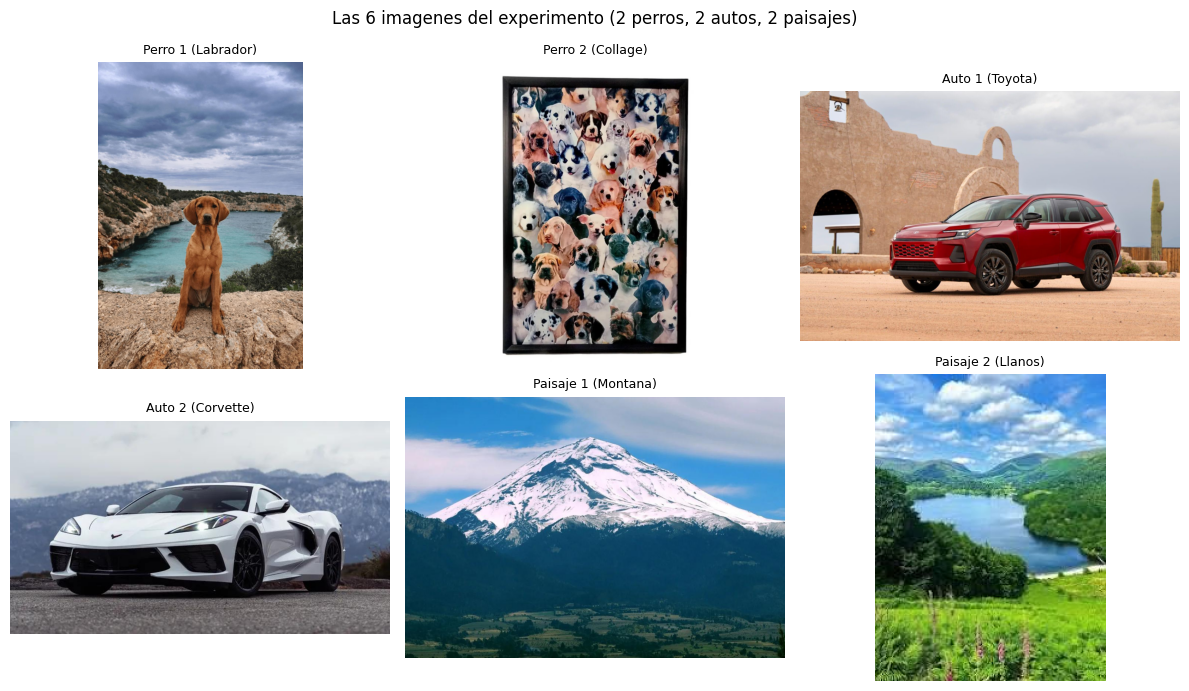

In [8]:
# Descargar las 6 imagenes y visualizarlas
# Imagenes libres de Wikimedia Commons, organizadas en 3 categorias:
# 2 perros, 2 autos, 2 paisajes

IMAGENES = {
    "Perro 1 (Labrador)":  "https://cdn-ilcmkfh.nitrocdn.com/yyMhcicvwELNLGXsIkJPkrkfmvWjNMQC/assets/images/optimized/rev-a314dca/labradoresdeabantueso.com/wp-content/uploads/2026/05/labrador-retriever-abantueso.png",
    "Perro 2 (Collage)":   "https://http2.mlstatic.com/D_NQ_NP_2X_872626-MLM80125378595_102024-F.webp",
    "Auto 1 (Toyota)":     "https://s3.amazonaws.com/static.latamautos.com/2026/03/2026_Toyota-RAV4-HEV_XLE_Premium_RubyFlarePearl_007_NR-1500x986.jpg",
    "Auto 2 (Corvette)":   "https://hips.hearstapps.com/mtg-prod/67b7d6cc3193690008b4d013/008-2025-chevrolet-corvette-012825.jpg?w=768&width=768&q=75&format=webp",
    "Paisaje 1 (Montana)": "https://masdemx.com/wp-content/uploads/2016/02/PopoAmeca2zoom-1-1024x705.jpg",
    "Paisaje 2 (Llanos)":  "https://encrypted-tbn0.gstatic.com/images?q=tbn:ANd9GcRqBZn_Jw0MVz692fCvab6rTe6MunON4KVVwr_pPbmcLg&s",
}

# Nota: si alguna URL falla por disponibilidad de Wikimedia, el codigo
# omite esa imagen y continua. Se necesitan al menos 4 imagenes para el heatmap.

print("Descargando imagenes...")
imagenes_pil = {}  # guardamos objetos PIL para usar despues en los experimentos

for nombre, url in IMAGENES.items():
    nombre_archivo = nombre.replace(" ", "_").replace("(", "").replace(")", "")
    ruta = ASSETS_DIR / f"{nombre_archivo}.jpg"
    try:
        if not ruta.exists():
            respuesta = requests.get(url, timeout=15)
            respuesta.raise_for_status()
            img = Image.open(BytesIO(respuesta.content)).convert("RGB")
            img.save(ruta)
        else:
            img = Image.open(ruta).convert("RGB")
        imagenes_pil[nombre] = img
        print(f"  ok {nombre}")
    except Exception as e:
        print(f"  ERROR {nombre}: {e}")

print(f"\n{len(imagenes_pil)} imagenes listas.")

# Advertencia si faltan imagenes
if len(imagenes_pil) < 4:
    print("\nADVERTENCIA: menos de 4 imagenes disponibles.")
    print("Guarda imagenes JPEG manualmente en:", ASSETS_DIR)
    print("y usa: imagenes_pil['Nombre'] = Image.open('ruta.jpg').convert('RGB')")

# Mostrar las imagenes disponibles en cuadricula
n_imgs = len(imagenes_pil)
cols   = min(3, n_imgs)
rows   = (n_imgs + cols - 1) // cols
fig, axes = plt.subplots(rows, cols, figsize=(cols * 4, rows * 3.5))
# Normalizar axes a lista plana para iterar uniformemente
if n_imgs == 1:
    axes = [axes]
else:
    axes = np.array(axes).flatten()

for ax, (nombre, img) in zip(axes, imagenes_pil.items()):
    ax.imshow(img)
    ax.set_title(nombre, fontsize=9)
    ax.axis("off")
# Ocultar ejes sobrantes si el numero de imagenes no llena la cuadricula
for ax in axes[n_imgs:]:
    ax.axis("off")

plt.suptitle("Las 6 imagenes del experimento (2 perros, 2 autos, 2 paisajes)", fontsize=12)
plt.tight_layout()
plt.show()


Calculando embeddings...


  ok Perro 1 (Labrador)
  ok Perro 2 (Collage)
  ok Auto 1 (Toyota)
  ok Auto 2 (Corvette)
  ok Paisaje 1 (Montana)
  ok Paisaje 2 (Llanos)

Construyendo matriz de similitud...


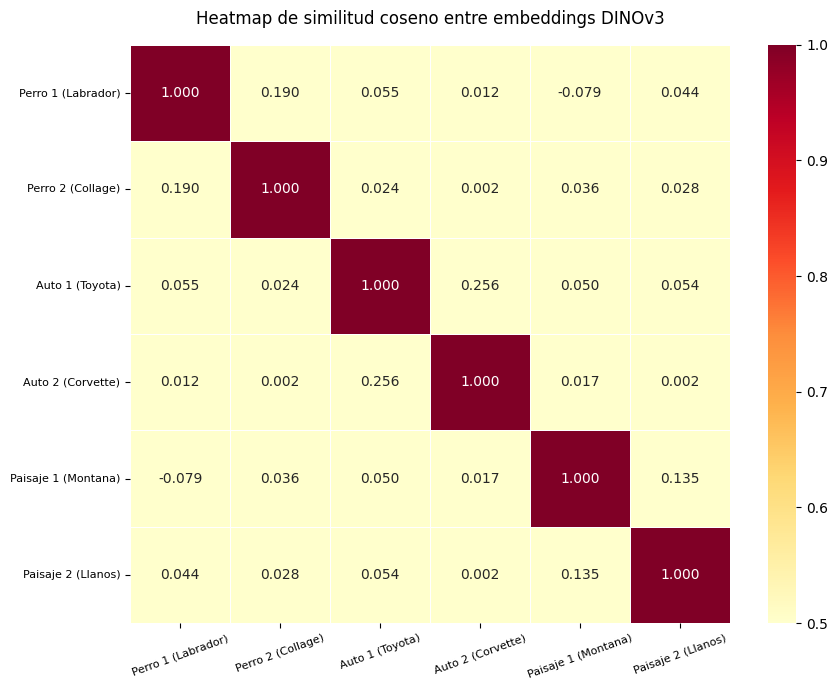


Observa los bloques en diagonal: imagenes de la misma categoria
tienen similitud mas alta que imagenes de categorias distintas.


In [9]:
# Calcular embeddings y construir heatmap de similitud

nombres = list(imagenes_pil.keys())
n = len(nombres)

# Calcular embedding para cada imagen
print("Calculando embeddings...")
embeddings = []
for nombre, img in imagenes_pil.items():
    inputs = processor(images=img, return_tensors="pt").to(device)
    with torch.no_grad():
        emb = model(**inputs).pooler_output
    embeddings.append(F.normalize(emb, dim=-1))
    print(f"  ok {nombre}")

# Construir matriz de similitud NxN
print("\nConstruyendo matriz de similitud...")
sim_matrix = np.zeros((n, n))
for i in range(n):
    for j in range(n):
        sim_matrix[i, j] = F.cosine_similarity(embeddings[i], embeddings[j]).item()

# Heatmap con seaborn
fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(
    sim_matrix,
    annot=True,
    fmt=".3f",
    cmap="YlOrRd",
    xticklabels=nombres,
    yticklabels=nombres,
    vmin=0.5,
    vmax=1.0,
    linewidths=0.5,
    ax=ax
)
ax.set_title("Heatmap de similitud coseno entre embeddings DINOv3", fontsize=12, pad=15)
ax.tick_params(axis="x", labelrotation=20, labelsize=8)
ax.tick_params(axis="y", labelrotation=0,  labelsize=8)
plt.tight_layout()
plt.show()

print("\nObserva los bloques en diagonal: imagenes de la misma categoria")
print("tienen similitud mas alta que imagenes de categorias distintas.")


Similitud coseno de cada transformacion vs. Original:

  Original                  1.0000  ########################################
  Espejo horizontal         0.9845  #######################################
  Oscurecida 50pct          0.9944  #######################################
  Recortada 70pct           0.9117  ####################################
  Rotada 30 grados          0.8500  #################################
  Escala de grises          0.9130  ####################################


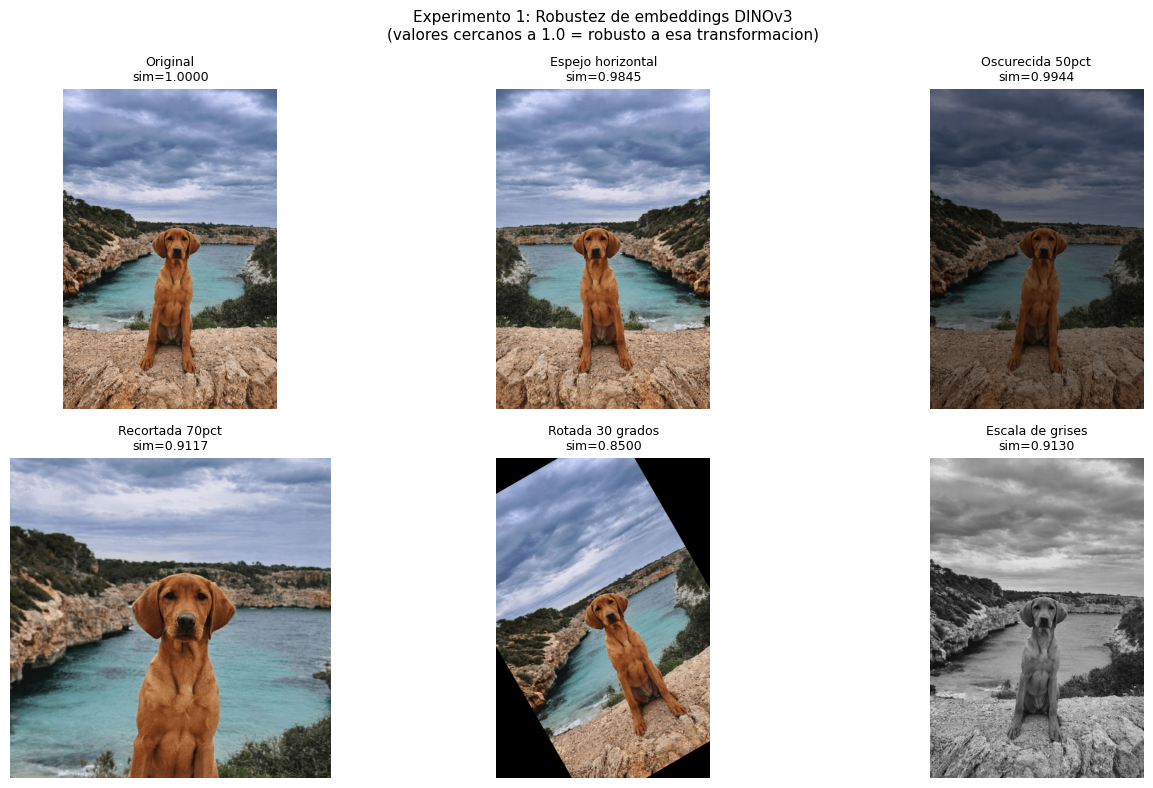

In [10]:
# Experimento 1: Robustez a transformaciones
import torchvision.transforms.functional as TF

# Imagen base: perro labrador (ya descargada en cell-14)
img_original = imagenes_pil["Perro 1 (Labrador)"]

# Aplicar 5 transformaciones usando torchvision.transforms.functional
transformaciones = {
    "Original":           img_original,
    "Espejo horizontal":  TF.hflip(img_original),
    "Oscurecida 50pct":   TF.adjust_brightness(img_original, 0.5),
    "Recortada 70pct":    TF.center_crop(img_original, min(img_original.size) * 7 // 10),
    "Rotada 30 grados":   TF.rotate(img_original, 30),
    "Escala de grises":   TF.to_grayscale(img_original, num_output_channels=3),
}

# Calcular embeddings para cada transformacion
emb_original_exp1 = None
embeddings_trans  = {}

for nombre, img in transformaciones.items():
    # Asegurar formato PIL
    if not isinstance(img, Image.Image):
        img = TF.to_pil_image(img)
    inputs = processor(images=img, return_tensors="pt").to(device)
    with torch.no_grad():
        emb = F.normalize(model(**inputs).pooler_output, dim=-1)
    embeddings_trans[nombre] = (emb, img)
    if nombre == "Original":
        emb_original_exp1 = emb

# Mostrar similitud de cada variante vs. el original
print("Similitud coseno de cada transformacion vs. Original:\n")
for nombre, (emb, _) in embeddings_trans.items():
    sim = F.cosine_similarity(emb_original_exp1, emb).item()
    barra = "#" * int(sim * 40)
    print(f"  {nombre:<25} {sim:.4f}  {barra}")

# Visualizar las transformaciones con su similitud
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
for ax, (nombre, (emb, img)) in zip(axes.flatten(), embeddings_trans.items()):
    sim = F.cosine_similarity(emb_original_exp1, emb).item()
    ax.imshow(img)
    ax.set_title(f"{nombre}\nsim={sim:.4f}", fontsize=9)
    ax.axis("off")

plt.suptitle(
    "Experimento 1: Robustez de embeddings DINOv3\n"
    "(valores cercanos a 1.0 = robusto a esa transformacion)",
    fontsize=11
)
plt.tight_layout()
plt.show()

# 💭 Reflexion: que transformaciones bajan mas la similitud?
# El modelo es mas sensible a cambios de forma (recorte, rotacion)
# o de color (escala de grises, brillo)?
# Un modelo robusto deberia mantener similitud alta en espejo y cambios de brillo,
# porque el contenido semantico (un perro) no cambia con esas transformaciones.


In [11]:
# Descargar 15 imagenes para clustering (5 por categoria)
# Todas las URLs son de Wikimedia Commons (licencia libre)

IMAGENES_CLUSTERING = {
    # --- Perros ---
    "perro_01": "https://s3.elespanol.com/2022/04/05/actualidad/662693892_223269480_1024x576.jpg",
    "perro_02": "https://s3.elespanol.com/2022/04/05/actualidad/662693902_223269778_1024x576.jpg",
    "perro_03": "https://s3.elespanol.com/2022/04/05/actualidad/662693941_223271048_1024x576.jpg",
    "perro_04": "https://s3.elespanol.com/2022/04/05/actualidad/662693943_223271106_1024x576.jpg",
    "perro_05": "https://s3.elespanol.com/2022/04/05/actualidad/662693981_223272340_1024x576.jpg",
    # --- Autos ---
    "auto_01":  "https://loscoches.com/wp-content/uploads/2022/07/comprar-carro-nuevo-colombia.jpg",
    "auto_02":  "https://loscoches.com/wp-content/uploads/2022/07/comprar-carro-nuevo-suv.jpg",
    "auto_03":  "https://loscoches.com/wp-content/uploads/2022/07/carro-nuevo-sedan.jpg",
    "auto_04":  "https://loscoches.com/wp-content/uploads/2024/02/2-Innovacion-electrica-en-vehiculos-Los-Coches.jpg",
    "auto_05":  "https://loscoches.com/wp-content/uploads/2024/02/4-Innovacion-electrica-en-vehiculos-Los-Coches.jpg",
    # --- Paisajes ---
    "paisaje_01": "https://www.foroambiental.net/archivo/images/foroambiental/lugar8.jpg",
    "paisaje_02": "https://www.foroambiental.net/archivo/images/foroambiental/lugares-7.jpg",
    "paisaje_03": "https://www.foroambiental.net/archivo/images/lugares-3.jpg",
    "paisaje_04": "https://www.foroambiental.net/archivo/images/lugares-2.jpg",
    "paisaje_05": "https://www.foroambiental.net/archivo/images/lugares-1.jpg",
}

# Etiquetas reales (para colorear el scatter — el modelo NO las vera)
ETIQUETAS_REALES = {
    "perro_01": "perro", "perro_02": "perro", "perro_03": "perro",
    "perro_04": "perro", "perro_05": "perro",
    "auto_01":  "auto",  "auto_02":  "auto",  "auto_03":  "auto",
    "auto_04":  "auto",  "auto_05":  "auto",
    "paisaje_01": "paisaje", "paisaje_02": "paisaje", "paisaje_03": "paisaje",
    "paisaje_04": "paisaje", "paisaje_05": "paisaje",
}

# Descargar imagenes con manejo de errores
print("Descargando 15 imagenes para clustering...")
imagenes_clustering = {}

for clave, url in IMAGENES_CLUSTERING.items():
    ruta = ASSETS_DIR / f"{clave}.jpg"
    try:
        if not ruta.exists():
            resp = requests.get(url, timeout=15)
            resp.raise_for_status()
            img  = Image.open(BytesIO(resp.content)).convert("RGB")
            img.save(ruta)
        else:
            img = Image.open(ruta).convert("RGB")
        imagenes_clustering[clave] = img
        print(f"  ok {clave}")
    except Exception as e:
        print(f"  ERROR {clave}: {e} (se omitira)")

n_ok = len(imagenes_clustering)
print(f"\n{n_ok} imagenes listas para clustering.")

# Advertencia si faltan demasiadas imagenes (K-Means necesita >=3 por cluster)
if n_ok < 9:
    print("ADVERTENCIA: se necesitan al menos 9 imagenes (3 por clase) para el experimento.")
    print("Algunas URLs de Wikimedia pueden no estar disponibles en tu red.")
    print("Agrega imagenes locales con: imagenes_clustering['clave'] = Image.open(...).convert('RGB')")


Descargando 15 imagenes para clustering...
  ok perro_01
  ok perro_02
  ok perro_03
  ok perro_04
  ok perro_05
  ok auto_01
  ok auto_02
  ok auto_03
  ok auto_04
  ok auto_05
  ok paisaje_01
  ok paisaje_02
  ok paisaje_03
  ok paisaje_04
  ok paisaje_05

15 imagenes listas para clustering.


In [12]:
# Funcion de busqueda en galeria

def buscar_similares(embedding_consulta: torch.Tensor,
                     galeria_embeddings: dict,
                     top_k: int = 3) -> list:
    """Encuentra las top_k imagenes mas similares en la galeria."""
    similitudes = []
    for clave, emb_galeria in galeria_embeddings.items():
        sim = F.cosine_similarity(embedding_consulta, emb_galeria).item()
        similitudes.append((clave, sim))
    # Ordenar de mayor a menor similitud
    similitudes.sort(key=lambda x: x[1], reverse=True)
    return similitudes[:top_k]


print("Funcion buscar_similares() definida.")


Funcion buscar_similares() definida.


In [13]:
# Pipeline completo: YOLO detecta, sv.crop_image recorta, DINOv3 busca similares
from ultralytics import YOLO as UltralyticsYOLO

# Verificar que la galeria esta disponible antes de continuar
if len(galeria_embeddings) == 0:
    raise RuntimeError("La galeria esta vacia. Ejecuta la celda anterior (build_gallery) primero.")

# Imagen de consulta: auto Toyota (ya descargada en Seccion 3)
img_consulta_pil = imagenes_pil["Auto 1 (Toyota)"]
img_consulta_np  = cv2.cvtColor(np.array(img_consulta_pil), cv2.COLOR_RGB2BGR)

print("Paso 1: Deteccion con YOLO...")
print("(yolov8n.pt se descarga ~6 MB la primera vez)")
yolo_model      = UltralyticsYOLO("yolov8n.pt")
resultados_yolo = yolo_model(img_consulta_np, verbose=False)[0]
detecciones     = sv.Detections.from_ultralytics(resultados_yolo)

print(f"  Objetos detectados: {len(detecciones)}")
for i, (bbox, cls_id, conf) in enumerate(
    zip(detecciones.xyxy, detecciones.class_id, detecciones.confidence)
):
    nombre_clase = resultados_yolo.names[cls_id]
    print(f"    [{i}] {nombre_clase} (conf={conf:.2f})  bbox={bbox.astype(int).tolist()}")

print("\nPaso 2: Recortar primera deteccion con sv.crop_image...")
# sv.crop_image(image, xyxy): recorta la region indicada por las coordenadas xyxy
# Requiere supervision >= 0.21
if len(detecciones) > 0:
    recorte_np  = sv.crop_image(image=img_consulta_np, xyxy=detecciones.xyxy[0])
    recorte_pil = Image.fromarray(cv2.cvtColor(recorte_np, cv2.COLOR_BGR2RGB))
    objeto_usado = f"{resultados_yolo.names[detecciones.class_id[0]]} (primera deteccion YOLO)"
else:
    # Fallback: usar imagen completa si YOLO no detecto nada en esta imagen
    print("  YOLO no detecto objetos — usando imagen completa como consulta.")
    recorte_pil  = img_consulta_pil
    recorte_np   = img_consulta_np
    objeto_usado = "imagen completa (fallback: YOLO no detecto objetos)"

print(f"  Objeto usado: {objeto_usado}")

print("\nPaso 3: Calcular embedding del recorte con DINOv3...")
inputs_recorte = processor(images=recorte_pil, return_tensors="pt").to(device)
with torch.no_grad():
    emb_recorte = F.normalize(model(**inputs_recorte).pooler_output, dim=-1)

print("\nPaso 4: Buscar en galeria...")
top3 = buscar_similares(emb_recorte, galeria_embeddings, top_k=3)

print("\n── Top 3 imagenes similares en la galeria ──────────────────")
for rank, (clave, sim) in enumerate(top3, 1):
    print(f"  [{rank}] {clave:<30} similitud={sim:.4f}")

# Visualizar: consulta + top 3 resultados
fig, axes = plt.subplots(1, 4, figsize=(16, 4))

# Panel de consulta con marco rojo
axes[0].imshow(recorte_pil)
axes[0].set_title("CONSULTA\n(recorte YOLO)", fontsize=9, color="red", fontweight="bold")
axes[0].axis("off")
for spine in axes[0].spines.values():
    spine.set_edgecolor("red")
    spine.set_linewidth(3)

# Paneles de resultados
for ax, (clave, sim) in zip(axes[1:], top3):
    rank = top3.index((clave, sim)) + 1
    ax.imshow(galeria_imagenes[clave])
    ax.set_title(f"Resultado #{rank}\n{clave}\nsim={sim:.4f}", fontsize=8)
    ax.axis("off")

plt.suptitle(
    "Pipeline YOLO + DINOv3 + Supervision\n"
    "Detectar --> Recortar (sv.crop_image) --> Buscar similares en galeria",
    fontsize=11, fontweight="bold"
)
plt.tight_layout()
plt.show()

# 💭 Reflexion: observa si los resultados top-3 pertenecen a la misma categoria
# que la imagen de consulta. Si YOLO recorto un auto, los resultados deberian
# ser autos de la galeria. Este es el patron basico de un motor de busqueda visual:
# detectar -> representar -> comparar -> recuperar.
print("\nEl pipeline funciona. Puedes reemplazar la imagen de consulta")
print("por cualquier imagen de tu dominio y la galeria por tu propio catalogo.")


NameError: name 'galeria_embeddings' is not defined